In [1]:
import sys
print(sys.executable)

/Users/parkjoyeong/Desktop/Park Joyeong/Career/study/hongong-machine-learning/.venv/bin/python


In [1]:
import torch
print(torch.backends.mps.is_available())

True


In [2]:
!wget https://github.com/rickiepark/hg-mldl2/raw/refs/heads/main/best_cnn_model.pt

--2026-09-20 14:22:52--  https://github.com/rickiepark/hg-mldl2/raw/refs/heads/main/best_cnn_model.pt
Resolving github.com (github.com)... 20.200.245.247
Connecting to github.com (github.com)|20.200.245.247|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/rickiepark/hg-mldl2/refs/heads/main/best_cnn_model.pt [following]
--2026-09-20 14:22:56--  https://raw.githubusercontent.com/rickiepark/hg-mldl2/refs/heads/main/best_cnn_model.pt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1337492 (1.3M) [application/octet-stream]
Saving to: ‘best_cnn_model.pt.1’

best_cnn_model.pt.1 100%[===================>]   1.28M  --.-KB/s    in 0.06s   

2026-09-20 14:22:56 (23.1 MB/s) - ‘best_cnn_model.pt.1’ saved [1

In [3]:
import torch.nn as nn

model = nn.Sequential()
model.add_module('conv1', nn.Conv2d(1, 32, kernel_size=3, padding='same'))
model.add_module('relu1', nn.ReLU())
model.add_module('pool1', nn.MaxPool2d(2))
model.add_module('conv2', nn.Conv2d(32, 64, kernel_size=3, padding='same'))
model.add_module('relu2', nn.ReLU())
model.add_module('pool2', nn.MaxPool2d(2))
model.add_module('flatten', nn.Flatten())
model.add_module('dense1', nn.Linear(3136, 100))
model.add_module('relu3', nn.ReLU())
model.add_module('dropout', nn.Dropout(0.3))
model.add_module('dense2', nn.Linear(100, 10))

In [4]:
device = torch.device(
    'mps' if torch.backends.mps.is_available() else 'cpu'
)

state_dict = torch.load(
    'best_cnn_model.pt',
    map_location='cpu',
    weights_only=True
)

model.load_state_dict(state_dict)
model.to(device)
print(device)

mps


In [5]:
layers = [layer for layer in model.children()]

In [6]:
print(layers[0])

Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)


In [7]:
model[0]

Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)

In [8]:
for name, layer in model.named_children():
    print(f"{name:10s}", layer)

conv1      Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
relu1      ReLU()
pool1      MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
conv2      Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
relu2      ReLU()
pool2      MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
flatten    Flatten(start_dim=1, end_dim=-1)
dense1     Linear(in_features=3136, out_features=100, bias=True)
relu3      ReLU()
dropout    Dropout(p=0.3, inplace=False)
dense2     Linear(in_features=100, out_features=10, bias=True)


In [9]:
model.conv1

Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)

In [10]:
conv1 = model.get_submodule('conv1')
assert isinstance(conv1, nn.Conv2d)

conv_weights = conv1.weight.data
print(conv_weights.mean(), conv_weights.std())

tensor(-0.0550, device='mps:0') tensor(0.3589, device='mps:0')


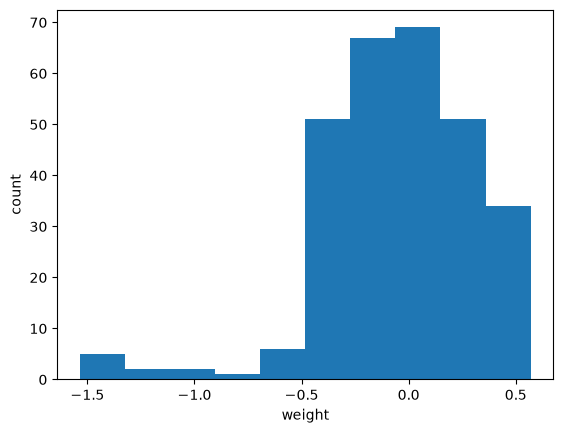

In [11]:
import matplotlib.pyplot as plt

conv_weights = conv_weights.detach().cpu()

plt.hist(conv_weights.reshape(-1, 1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

In [12]:
print(conv_weights.shape)

torch.Size([32, 1, 3, 3])


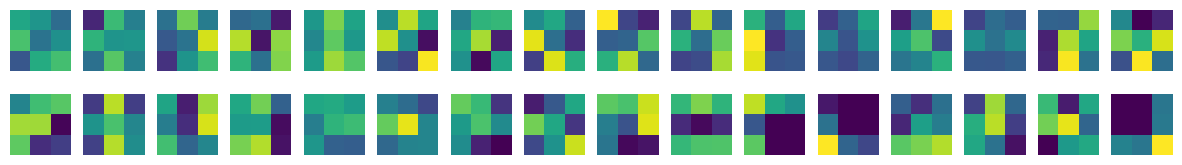

In [13]:
fig, axs = plt.subplots(2, 16, figsize=(15,2))
for i in range(2):
    for j in range(16):
        axs[i, j].imshow(conv_weights[i*16 + j,0,:,:], vmin=-0.5, vmax=0.5)
        axs[i, j].axis('off')
plt.show()

In [14]:
from torchvision.datasets import FashionMNIST

fm_train = FashionMNIST(root='.', train=True, download=True)
train_input = fm_train.data

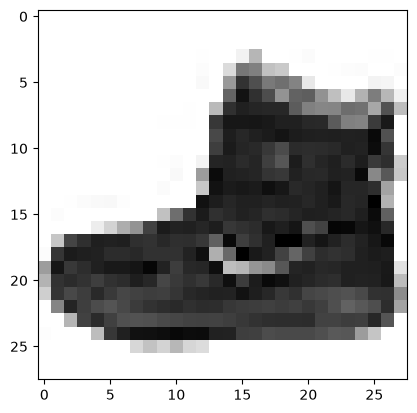

In [15]:
plt.imshow(train_input[0], cmap='gray_r')
plt.show()

In [16]:
device = next(model.parameters()).device

ankle_boot = (
    train_input[0:1]
    .reshape(1, 1, 28, 28)
    .float()
    .div(255.0)
    .to(device)
)

relu1 = model.get_submodule('relu1')
assert isinstance(relu1, nn.ReLU)


model.eval()
with torch.no_grad():
    feature_maps = conv1(ankle_boot)
    feature_maps = relu1(feature_maps)

In [17]:
print(feature_maps.shape)

torch.Size([1, 32, 28, 28])


In [19]:
model.to('cpu')

Sequential(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dense1): Linear(in_features=3136, out_features=100, bias=True)
  (relu3): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (dense2): Linear(in_features=100, out_features=10, bias=True)
)

In [21]:
ankle_boot = train_input[0:1].reshape(1, 1, 28, 28) / 255.0

conv1 = model.get_submodule('conv1')
relu1 = model.get_submodule('relu1')

model.eval()

with torch.no_grad():
    feature_maps = conv1(ankle_boot)
    feature_maps = relu1(feature_maps)

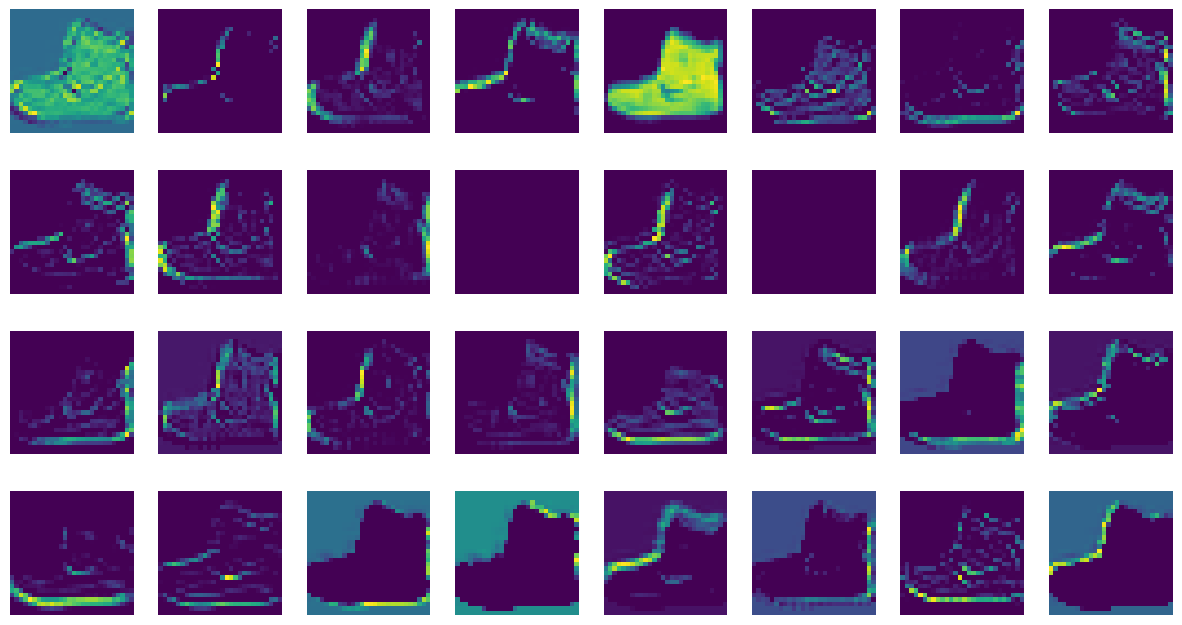

In [22]:
fig, axs = plt.subplots(4, 8, figsize=(15,8))
for i in range(4):
    for j in range(8):
        axs[i, j].imshow(feature_maps[0,i*8 + j,:,:])
        axs[i, j].axis('off')
plt.show()

In [23]:
model.eval()
with torch.no_grad():
    feature_maps = model.conv1(ankle_boot)
    feature_maps = model.relu1(feature_maps)
    feature_maps = model.pool1(feature_maps)
    feature_maps = model.conv2(feature_maps)
    feature_maps = model.relu2(feature_maps)

In [24]:
model.eval()
x = ankle_boot
with torch.no_grad():
    for name, layer in model.named_children():
        x = layer(x)
        if name == 'relu2':
            break
feature_maps = x

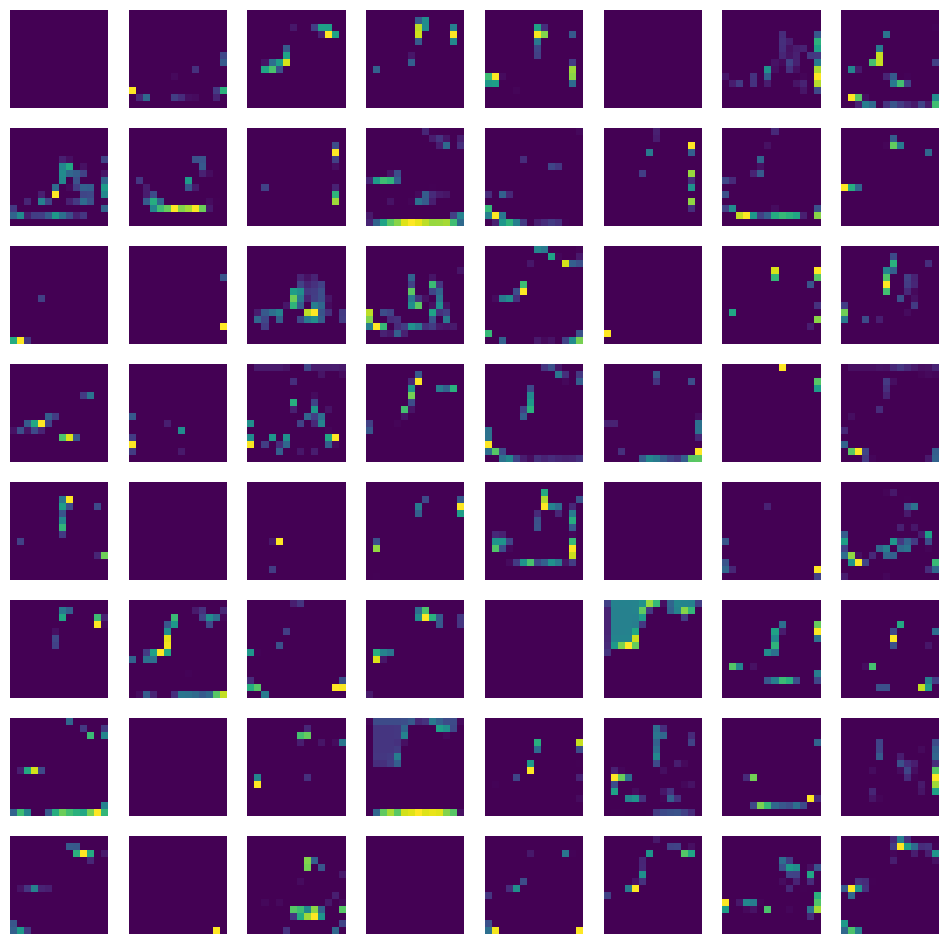

In [25]:
fig, axs = plt.subplots(8, 8, figsize=(12,12))
for i in range(8):
    for j in range(8):
        axs[i, j].imshow(feature_maps[0,i*8 + j,:,:])
        axs[i, j].axis('off')
plt.show()